   ID  Before  After4weeks  After8weeks Margarine
0   1    6.42         5.83         5.75         B
1   2    6.76         6.20         6.13         B
2   3    6.56         5.83         5.71         B
3   4    4.80         4.27         4.15         A
4   5    8.43         7.71         7.67         B
   ID Margarine    Time  Cholesterol
0   1         B  Before         6.42
1   2         B  Before         6.76
2   3         B  Before         6.56
3   4         A  Before         4.80
4   5         B  Before         8.43

Descriptive Statistics
                       count     mean       std      skew
Margarine Time                                           
A         After4weeks      8  5.46875  1.387603  0.199789
          After8weeks      8  5.40875  1.373707  0.171856
          Before           8  5.94500  1.428126  0.023557
B         After4weeks     10  6.14000  0.814589  0.880644
          After8weeks     10  6.07500  0.778835  1.123985
          Before          10  6.77800  0.866472 

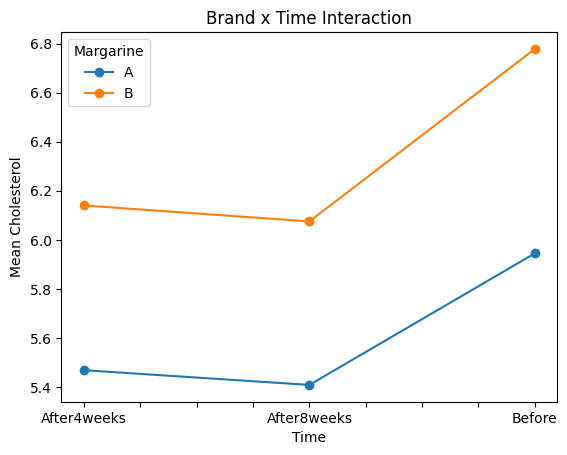

A two-way mixed ANOVA revealed a non-significant main effect of margarine brand, F(1,16) = 1.90, p = .187, ηp² = .11. 
There was a significant main effect of time, F(2,32) = 259.95, p < .001, ηp² = .94, indicating that cholesterol levels changed over time. 
The Brand × Time interaction was significant, F(2,32) = 4.81, p = .015, ηp² = .23, suggesting that cholesterol changed differently across time depending on margarine brand.


In [12]:
import pandas as pd
import pingouin as pg
from scipy.stats import shapiro, levene
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Cholesterol_R2.csv")

print(df.head())

# Reshape wide to long
long_df = pd.melt(
    df,
    id_vars=['ID','Margarine'],
    value_vars=['Before','After4weeks','After8weeks'],
    var_name='Time',
    value_name='Cholesterol'
)

print(long_df.head())

# --------------------------
# DESCRIPTIVE STATISTICS
# --------------------------
desc = long_df.groupby(['Margarine','Time'])['Cholesterol'].agg(
    ['count','mean','std','skew']
)

print("\nDescriptive Statistics")
print(desc)


# --------------------------
# ASSUMPTION CHECKS
# --------------------------

# Shapiro-Wilk Normality
print("\nShapiro-Wilk Tests")
for g in long_df.groupby(['Margarine','Time']):
    
    stat,p = shapiro(g[1]['Cholesterol'])
    print(g[0], "W =", round(stat,3),
          "p =", round(p,4))


# Levene Test
groups = [
group["Cholesterol"].values
for name,group in long_df.groupby(['Margarine','Time'])
]

stat,p = levene(*groups)

print("\nLevene Test")
print("Statistic:",stat)
print("p-value:",p)


# --------------------------
# TWO-WAY MIXED ANOVA
# --------------------------

anova = pg.mixed_anova(
dv='Cholesterol',
within='Time',
between='Margarine',
subject='ID',
data=long_df
)

print("\nMixed ANOVA")
print(anova)


# --------------------------
# POST HOC TESTS
# --------------------------

posthoc = pg.pairwise_tests(
    data=long_df,
    dv='Cholesterol',
    within='Time',
    subject='ID',
    padjust='bonf',
    within_first=True
)

print(posthoc)


# --------------------------
# INTERACTION PLOT
# --------------------------

means = long_df.groupby(
['Time','Margarine']
)['Cholesterol'].mean().unstack()

means.plot(marker='o')
plt.ylabel("Mean Cholesterol")
plt.title("Brand x Time Interaction")
plt.show()

print("A two-way mixed ANOVA revealed a non-significant main effect of margarine brand, F(1,16) = 1.90, p = .187, ηp² = .11. \nThere was a significant main effect of time, F(2,32) = 259.95, p < .001, ηp² = .94, indicating that cholesterol levels changed over time. \nThe Brand × Time interaction was significant, F(2,32) = 4.81, p = .015, ηp² = .23, suggesting that cholesterol changed differently across time depending on margarine brand.")